Lets read the imputed version of each dataset.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../src
import sys
sys.path.append("../src/")

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from cast_utility import cast_column_to_Int64
import seaborn as sbn
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [4]:
races=pd.read_csv('../dataset/preprocessedRaces.csv', sep=",")
placements=pd.read_csv('../dataset/preprocessedPlacements.csv', sep=",")
cyclists=pd.read_csv('../dataset/preprocessedCyclists.csv', sep=",")

# Imputazione profile

In [5]:
from distribution_utility import stats_and_distribution

Description of attribute 'profile':


count     2873.0
unique       5.0
top          2.0
freq       867.0
Name: profile, dtype: float64


Unique values:
[1.0 5.0 nan 3.0 2.0 4.0]

Null values: 2408 over 5281 records - (45.60%)

Top 5 most frequent values:
profile
2.0    867
1.0    817
5.0    575
3.0    327
4.0    287
Name: count, dtype: int64


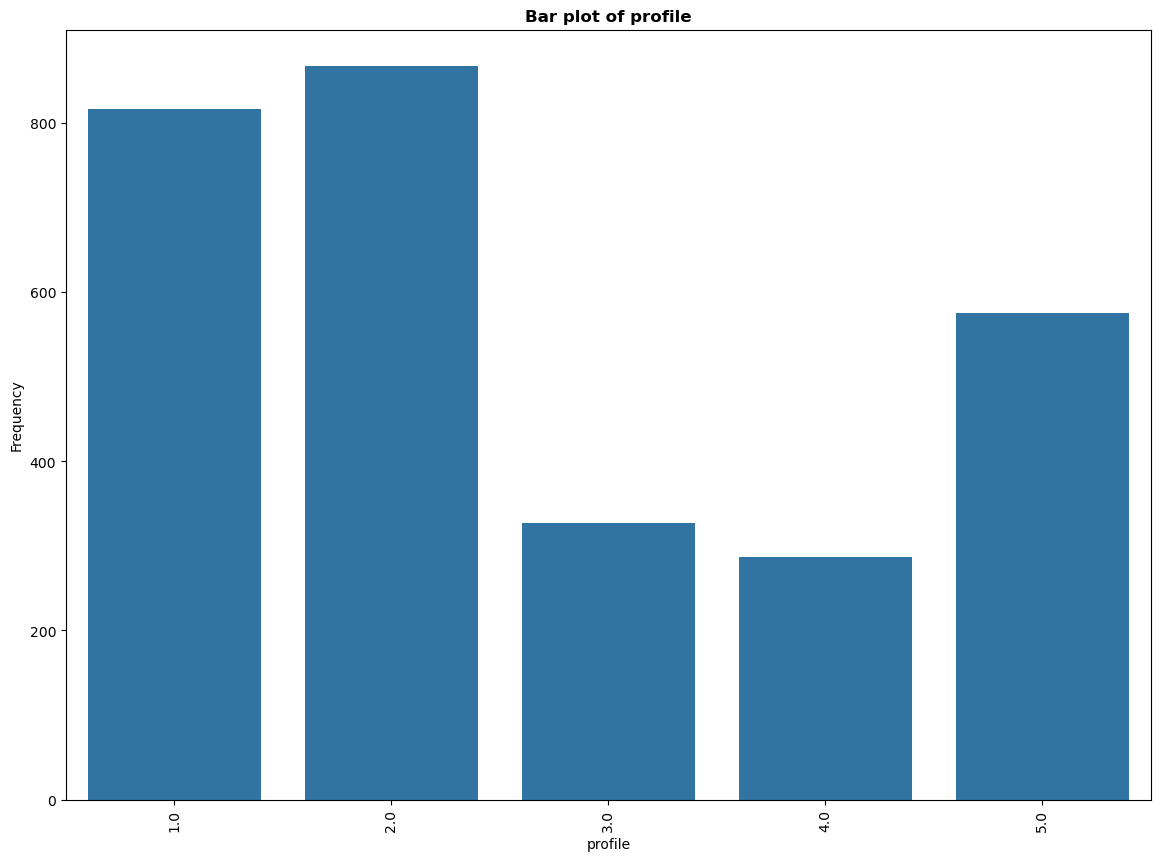

In [6]:
stats_and_distribution(races, 'profile', 'categorical')

In [7]:
races['climb/length'].isna().any()

False

In [8]:
for i in sorted(races[races['profile'].notna()]['profile'].unique()):
    print(f"----- PROFILE {i} -----")
    print(races[races['profile']==i]['climb/length'].describe())

----- PROFILE 1.0 -----
count    817.000000
mean       0.008081
std        0.004718
min        0.000069
25%        0.005191
50%        0.007845
75%        0.010229
max        0.044000
Name: climb/length, dtype: float64
----- PROFILE 2.0 -----
count    867.000000
mean       0.012952
std        0.004319
min        0.001265
25%        0.009786
50%        0.012626
75%        0.015676
max        0.046053
Name: climb/length, dtype: float64
----- PROFILE 3.0 -----
count    327.000000
mean       0.014262
std        0.004411
min        0.005415
25%        0.011479
50%        0.014025
75%        0.016459
max        0.036418
Name: climb/length, dtype: float64
----- PROFILE 4.0 -----
count    287.000000
mean       0.019497
std        0.005109
min        0.003159
25%        0.015868
50%        0.019005
75%        0.023461
max        0.032583
Name: climb/length, dtype: float64
----- PROFILE 5.0 -----
count    575.000000
mean       0.024847
std        0.011070
min        0.001901
25%        0.019022


We have decided that the imputation of the profile feature will be guided by the ratio _climb/length_, since it has a greater Kendall correlation score than the feature 'climb_total'. This result is reported in the notebook section where we have defined this novel feature. <br>
The statistics reported above show that is difficult to define ranges for the ratio in order to assign the proper 'profile' label, since there is an overlap for some profiles. For this reason the imputation is done by selecting the profile which has the nearest mean to our current climb/length ratio.

In [9]:
races_preImputation=races.copy()

In [10]:
#determine the mean clime/length ratio for each profile
profile_means = races.groupby('profile')['climb/length'].mean()
print("Mean climb/length ratio per profile\n",profile_means)

def impute_profile_by_mean(climb_length):
    # returns the index of the profile with the lowest distance with its mean value for the ratio
    return profile_means.sub(climb_length).abs().idxmin()

#imputation
races['profile'] = races['profile'].fillna(races['climb/length'].apply(impute_profile_by_mean))


Mean climb/length ratio per profile
 profile
1.0    0.008081
2.0    0.012952
3.0    0.014262
4.0    0.019497
5.0    0.024847
Name: climb/length, dtype: float64


Description of attribute 'profile':


count     5281.0
unique       5.0
top          1.0
freq      1757.0
Name: profile, dtype: float64


Unique values:
[1.0 5.0 3.0 2.0 4.0]

Null values: 0 over 5281 records - (0.00%)

Top 5 most frequent values:
profile
1.0    1757
2.0    1355
3.0     845
5.0     742
4.0     582
Name: count, dtype: int64


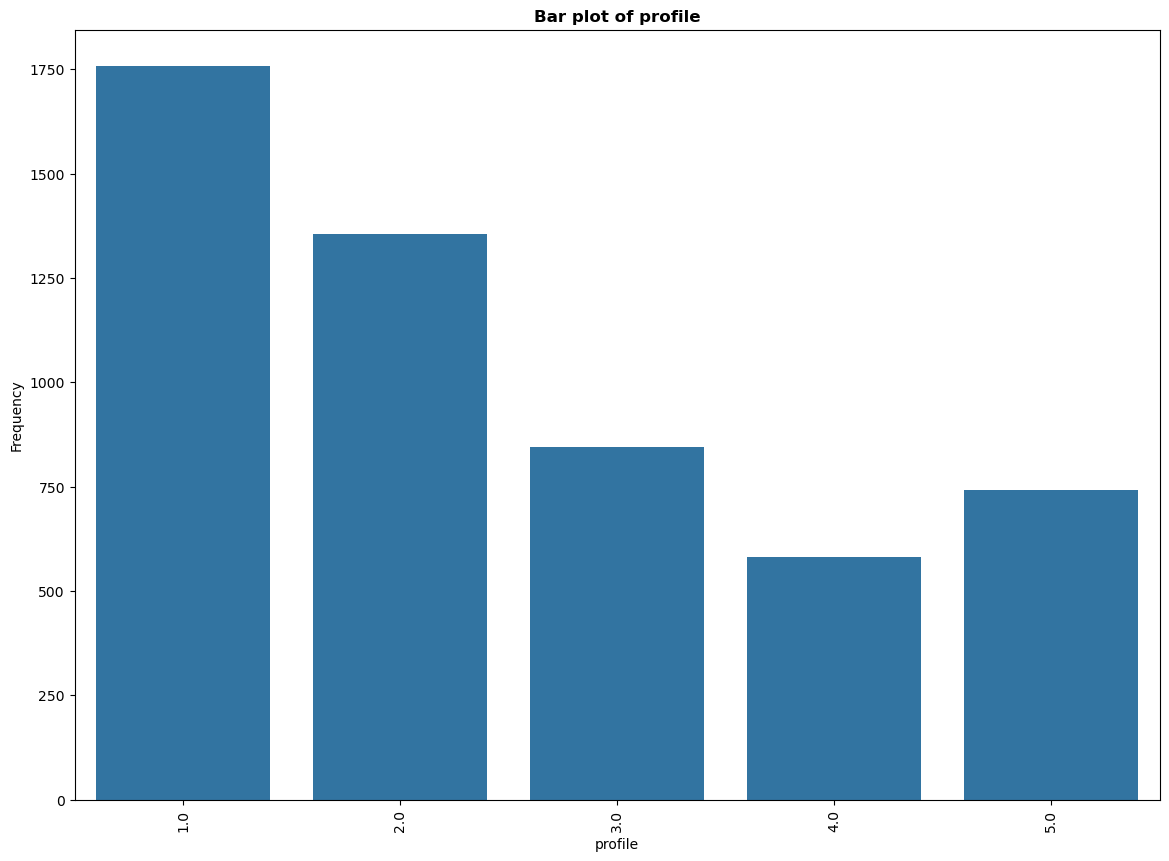

In [11]:
stats_and_distribution(races, 'profile', 'categorical')

The imputation has assigned the profile 1 to many races, in fact before the imputation the most populated profile was 2. This variation in the distribution, in some sense, cannot be avoidable since perhaps most of the races with a NaN profile have a short climb total value. Since about 42% of the races have a missing climb total information, its imputation strategy using the KNN may have influenced also the imputation of that profile.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sbn
import matplotlib.colors as mcolors

def show_side_by_side_bar_plots(df1, df2, column_name):
    values1 = df1[column_name].dropna()
    values_count1 = values1.value_counts().sort_index()
    percentages1 = (values_count1 / len(values1)) * 100

    values2 = df2[column_name].dropna()
    values_count2 = values2.value_counts().sort_index()
    percentages2 = (values_count2 / len(values2)) * 100

    # Coherent palette for each graph
    unique_values = sorted(set(values1.unique()).union(set(values2.unique())))
    colors = sbn.color_palette("Set2", len(unique_values))  # A color for each unique value
    color_map = {val: colors[i] for i, val in enumerate(unique_values)} 

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

    # First barplot (pre-imputation)
    sbn.barplot(
        x=values_count1.index, 
        y=values_count1.values, 
        ax=axes[0], 
        palette=[color_map[val] for val in values_count1.index]
    )
    axes[0].set_title(f'Bar plot of {column_name} pre-imputation', fontweight='bold')
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Frequency')
    for i, (v, perc) in enumerate(zip(values_count1.values, percentages1)):
        axes[0].text(i, v + max(values_count1.values) * 0.02, f'{perc:.1f}%', ha='center')

    # Second barplot (after imputation)
    sbn.barplot(
        x=values_count2.index, 
        y=values_count2.values, 
        ax=axes[1], 
        palette=[color_map[val] for val in values_count2.index]
    )
    axes[1].set_title(f'Bar plot of {column_name} after imputation', fontweight='bold')
    axes[1].set_xlabel(column_name)
    axes[1].set_ylabel('Frequency')
    for i, (v, perc) in enumerate(zip(values_count2.values, percentages2)):
        axes[1].text(i, v + max(values_count2.values) * 0.02, f'{perc:.1f}%', ha='center')

    plt.tight_layout()
    plt.show()

C:\Users\simon\AppData\Local\Temp\ipykernel_1944\1449849370.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.barplot(
C:\Users\simon\AppData\Local\Temp\ipykernel_1944\1449849370.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.barplot(


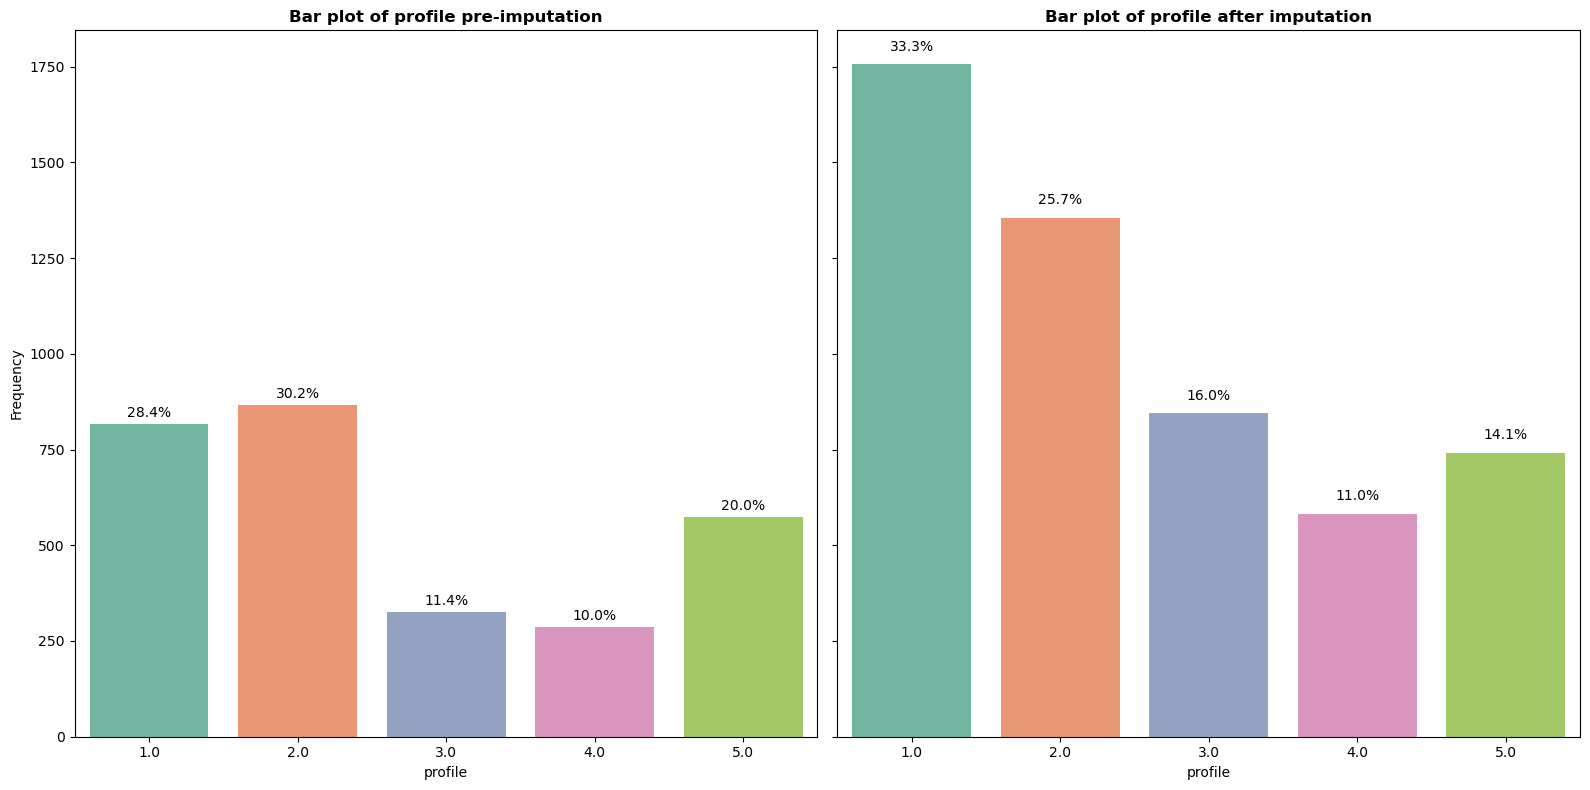

In [13]:
show_side_by_side_bar_plots(races_preImputation,races, 'profile')

# Classification

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint as sp_randint
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report

In [15]:
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

### Data preparation

Reconstruction of the original dataset by merging the three dataset produced for the previous tasks. We do not include in the final dataset those columns excluded from the analysis due not resolved data quality issues or because of redundancy. 

In [16]:
cyclists.drop(['AVG weighted position', 'AVG position Autumn', 'AVG position Spring', 'AVG position Summer', 'AVG position Winter', 'AVG position Q1', 'AVG position Q2', 'AVG position Q3', 'AVG position Q4'], axis=1, inplace=True)
cyclists.columns

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'nationality', 'continent', 'geo area', 'birth_year',
       'std_dev position'],
      dtype='object')

In [17]:
races.drop(['uci_points', 'average_temperature', 'is_tarmac', 'is_cobbled', 'is_gravel'], axis=1, inplace=True)
races.columns

Index(['_url', 'name', 'points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'date', 'climb/length', 'median_delta',
       'std_delta'],
      dtype='object')

In [18]:
placements.drop(['cyclist_team'], axis=1, inplace=True)
placements.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', 'date', '_url', 'year'], dtype='object')

In [19]:
placements.head()

,position,cyclist,cyclist_age,delta,date,_url,year
0,0,georges-pintens,24,0,1970-04-25,amstel-gold-race/1970/result,1970
1,1,willy-van-neste,26,0,1970-04-25,amstel-gold-race/1970/result,1970
2,2,andre-dierickx,23,22,1970-04-25,amstel-gold-race/1970/result,1970
3,3,eric-leman,24,33,1970-04-25,amstel-gold-race/1970/result,1970
4,4,joseph-schoeters,23,33,1970-04-25,amstel-gold-race/1970/result,1970


In [20]:
dataset=pd.merge(placements, races, how='inner', on='_url')

In [21]:
dataset.drop(['date_y', 'date_x'], axis=1, inplace=True)

In [22]:
dataset=pd.merge(placements, cyclists, how='inner', left_on='cyclist', right_on='name')

In [23]:
dataset

,position,cyclist,cyclist_age,delta,date,_url,year,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,std_dev position
0,0,georges-pintens,24,0,1970-04-25,amstel-gold-race/1970/result,1970,georges-pintens,22.057578,4,13,37,Belgium,Europe,Western Europe,1946.0,18.685480
1,1,willy-van-neste,26,0,1970-04-25,amstel-gold-race/1970/result,1970,willy-van-neste,18.646937,6,10,10,Belgium,Europe,Western Europe,1944.0,8.141116
2,2,andre-dierickx,23,22,1970-04-25,amstel-gold-race/1970/result,1970,andre-dierickx,22.840000,8,16,67,Belgium,Europe,Western Europe,1947.0,18.234961
3,3,eric-leman,24,33,1970-04-25,amstel-gold-race/1970/result,1970,eric-leman,21.748939,4,7,38,Belgium,Europe,Western Europe,1946.0,7.836705
4,4,joseph-schoeters,23,33,1970-04-25,amstel-gold-race/1970/result,1970,joseph-schoeters,22.727257,19,20,7,Belgium,Europe,Western Europe,1947.0,9.860938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589860,98,daan-hoole,23,688,2022-09-25,world-championship/2022/result,2022,daan-hoole,20.760000,96,96,34,Netherlands,Europe,Western Europe,1999.0,42.013155
589861,99,ben-turner,23,700,2022-09-25,world-championship/2022/result,2022,ben-turner,19.660000,88,83,44,Great Britain,Europe,Northern Europe,1999.0,43.267861
589862,100,pavel-sivakov,25,868,2022-09-25,world-championship/2022/result,2022,pavel-sivakov,19.810000,40,52,171,France,Europe,Western Europe,1997.0,40.043803
589863,101,jake-stewart,23,905,2022-09-25,world-championship/2022/result,2022,jake-stewart,20.600000,87,72,53,Great Britain,Europe,Northern Europe,1999.0,43.685776


In [24]:
#Remove the columns that act as identifiers of races/cyclists.
# *TODO* Vedere se le colonne ridondanti si possono levare e verificare come gestire le date
dataset.drop(['cyclist', '_url', 'date', 'name'], axis=1, inplace=True)

In [25]:
dataset.columns

Index(['position', 'cyclist_age', 'delta', 'year', 'BMI', 'median position',
       'AVG position', '# cyclist races', 'nationality', 'continent',
       'geo area', 'birth_year', 'std_dev position'],
      dtype='object')

In [26]:
#check if there is any null value
dataset.isnull().values.any()

False

In [27]:
#input: the dataset and the list of variables' names to encode
def categorical_columns_encoding(dataset, variables):
    for variable in variables:
        #get the unique variable's values
        var = sorted(dataset[variable].unique())
        
        #generate a mapping from the variable's values to the number representation  
        mapping = dict(zip(var, range(0, len(var) + 1)))

        #add a new colum with the number representation of the variable
        dataset[variable+'_num'] = dataset[variable].map(mapping).astype(int)
    return dataset

In [28]:
categorical_columns = ['geo area', 'nationality', 'continent']
dataset = categorical_columns_encoding(dataset, categorical_columns).drop(categorical_columns,axis=1)

In [29]:
dataset.head()

,position,cyclist_age,delta,year,BMI,median position,AVG position,# cyclist races,birth_year,std_dev position,geo area_num,nationality_num,continent_num
0,0,24,0,1970,22.057578,4,13,37,1946.0,18.685480,7,7,3
1,1,26,0,1970,18.646937,6,10,10,1944.0,8.141116,7,7,3
2,2,23,22,1970,22.840000,8,16,67,1947.0,18.234961,7,7,3
3,3,24,33,1970,21.748939,4,7,38,1946.0,7.836705,7,7,3
4,4,23,33,1970,22.727257,19,20,7,1947.0,9.860938,7,7,3


Let's generate the *class binary label* TOP20, which takes 1 as value if the position of the placement is in the range [0, 19], 0 otherwise.

In [30]:
dataset['top20'] = (dataset['position'] < 20).astype(int)

In [31]:
original_size=dataset.shape[0]
test_set=dataset[dataset['year']>=2022]
dataset=dataset[dataset['year']<2022]
print(f"Test set size: {test_set.shape[0]} ({test_set.shape[0] * 100 / original_size:.2f}%)")
print(f"Training set size: {dataset.shape[0]} ({dataset.shape[0] * 100 / original_size:.2f}%)")

Test set size: 35406 (6.00%)
Training set size: 554459 (94.00%)


The test set should never be used to perform the hyperparameter tuning and the model selection. Since we have a good number of training data, we decide to extract from it a specific _validation set_. In particular we perform a stratified train/test split in order to preserve the initial proportion between the two classes.

In [32]:
test_top20_counts = test_set['top20'].value_counts(normalize=True)
dataset_top20_counts = dataset['top20'].value_counts(normalize=True)

results = pd.DataFrame({
    'Test Set': test_top20_counts,
    'Training Set': dataset_top20_counts
})
print(results)

       Test Set  Training Set
top20                        
0      0.860476      0.837871
1      0.139524      0.162129


In [33]:
label=dataset.pop('top20') 
test_label=test_set.pop('top20') #labels for the test set
# Extraction of the validation set
train_set, validation_set, train_label, validation_label = train_test_split(dataset, label, stratify =label, test_size=0.30, random_state=RANDOM_STATE)

In [34]:
training_top20_counts = train_label.value_counts(normalize=True)
validation_top20_counts = validation_label.value_counts(normalize=True)

results = pd.DataFrame({
    'Training Set': training_top20_counts,
    'Validation Set': validation_top20_counts,
    'Test Set': test_top20_counts
})
print(results)

print(f"Training set size: {train_set.shape[0]} ({train_set.shape[0] * 100 / original_size:.2f}%)")
print(f"Validation set size: {validation_set.shape[0]} ({validation_set.shape[0] * 100 / original_size:.2f}%)")
print(f"Test set size: {test_set.shape[0]} ({test_set.shape[0] * 100 / original_size:.2f}%)")

       Training Set  Validation Set  Test Set
top20                                        
0           0.83787        0.837872  0.860476
1           0.16213        0.162128  0.139524
Training set size: 388121 (65.80%)
Validation set size: 166338 (28.20%)
Test set size: 35406 (6.00%)


We immediately notice the fact that we are in an "unbalanced" context, with a minority '1' class.

## Decision Tree

**Parameters**: <br>
- `max_depth`: Controls the maximum depth of the tree; If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples. If too high the DT can better describe the training data but there is the risk of overfitting.
- `min_samples_split`: The minimum number of samples required to split an internal node.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. 
- `max_features`: The number of features to consider when looking for the best split.
- `criterion`: The function to measure the quality of a split. 
- `split`: The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.
"squared_error" (o "friedman_mse") per regressione.

In [35]:
#define a decision tree and fit it
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', 
                                  max_depth=10, 
                                  min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(train_set, train_label)

In [36]:
#predict using the decision tree
#the predict function returns the actual predicted labels: we need them for the evaluation phase
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)
test_pred_dt = dt.predict(test_set)

In [37]:
#evaulate the accuracy on the train set and the test set
#metrics also contains precision, recall, f1 and the support
from sklearn import metrics
print('Accuracy train set ', metrics.accuracy_score(train_label, train_pred_dt))
print('Accuracy test set ', metrics.accuracy_score(validation_label, valid_pred_dt))
print('Accuracy validation set ', metrics.accuracy_score(test_label, test_pred_dt))
print('--------------------')
print('Precision train set ', metrics.precision_score(train_label, train_pred_dt, average='weighted'))
print('Recall train set ', metrics.recall_score(train_label, train_pred_dt, average='weighted'))
print('F1 score train set ', metrics.f1_score(train_label, train_pred_dt, average='weighted'))
print('Support train set ', metrics.precision_recall_fscore_support(train_label, train_pred_dt))

Accuracy train set  1.0
Accuracy test set  1.0
Accuracy validation set  1.0
--------------------
Precision train set  1.0
Recall train set  1.0
F1 score train set  1.0
Support train set  (array([1., 1.]), array([1., 1.]), array([1., 1.]), array([325195,  62926], dtype=int64))


In [40]:
print('Training set results')
print(classification_report(train_label, train_pred_dt, target_names=['top20', 'Not top20']))
print('--------------------')
print('Validation set results')
print(classification_report(validation_label, valid_pred_dt, target_names=['top20', 'Not top20']))
print('--------------------')
print('Test set results')
print(classification_report(test_label, test_pred_dt, target_names=['top20', 'Not top20']))

Training set results
              precision    recall  f1-score   support

       top20       1.00      1.00      1.00    325195
   Not top20       1.00      1.00      1.00     62926

    accuracy                           1.00    388121
   macro avg       1.00      1.00      1.00    388121
weighted avg       1.00      1.00      1.00    388121

--------------------
Validation set results
              precision    recall  f1-score   support

       top20       1.00      1.00      1.00    139370
   Not top20       1.00      1.00      1.00     26968

    accuracy                           1.00    166338
   macro avg       1.00      1.00      1.00    166338
weighted avg       1.00      1.00      1.00    166338

--------------------
Test set results
              precision    recall  f1-score   support

       top20       1.00      1.00      1.00     30466
   Not top20       1.00      1.00      1.00      4940

    accuracy                           1.00     35406
   macro avg       1.00  

In this first attempt we notice that we obtain the 1 score for all the training, validation and test sets. This may due to the fact that the model is overfitting our data. We can actuate this mitigations:
- tune the parameters that control the complexity of the model such as _max\_depth_, _min\_samples\_split_, _min\_sample\_leaf_.
- use the cross validation.
- properly set the weights of the two classes, since we are in an unbalanced context. We can also test some techniques like the Oversampling/Undersampling.

In [42]:
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=5, min_samples_split=10, min_samples_leaf=4)
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [43]:
#evaulate the accuracy on the train set and the test set
#metrics also contains precision, recall, f1 and the support

print('Accuracy train set ', metrics.accuracy_score(train_label, train_pred_dt))
print('Accuracy test set ', metrics.accuracy_score(validation_label, valid_pred_dt))
print('Precision train set ', metrics.precision_score(train_label, train_pred_dt, average='weighted'))
print('Recall train set ', metrics.recall_score(train_label, train_pred_dt, average='weighted'))
print('F1 score train set ', metrics.f1_score(train_label, train_pred_dt, average='weighted'))
print('Support train set ', metrics.precision_recall_fscore_support(train_label, train_pred_dt))

Accuracy train set  1.0
Accuracy test set  1.0
Precision train set  1.0
Recall train set  1.0
F1 score train set  1.0
Support train set  (array([1., 1.]), array([1., 1.]), array([1., 1.]), array([325195,  62926], dtype=int64))


Try a Randomized GridSearch to find the best parameters of the model, including the weights given to each class.

In [50]:
def GridSearchCVExecution(hyperparameters, classifier, training_data, training_label, cross_validation=None, n_iterations=None):
    if n_iterations!=None:
        grid_search = RandomizedSearchCV(
                            classifier,
                            param_distributions=hyperparameters, 
                            n_iter=n_iterations, 
                            n_jobs=-1, 
                            scoring='roc_auc',
                            cv=cross_validation,
                            random_state=RANDOM_STATE,
                            )
    else:
        grid_search = RandomizedSearchCV(
                            classifier,
                            param_distributions=hyperparameters, 
                            n_jobs=-1, 
                            scoring='roc_auc',
                            cv=cross_validation,
                            random_state=RANDOM_STATE)
    grid_search.fit(training_data, training_label)
    return grid_search
    

In [51]:
#to find the best set of parameter setting, we can run a grid search

#Definition of the hyperparameters to test
#Class_weight['balanced'] assigns the weights in a way proportional to the # of samples
param_dist = {"max_depth": [2,3,4,5,6,7,8,9,10,12,20,None],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(10, 51),
              "min_samples_leaf": sp_randint(10, 51),
              "criterion": ["entropy", "gini"],
              "class_weight":['balanced', None, {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 15}, {0: 1, 1: 30}]
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 100
#define the model
classifier = tree.DecisionTreeClassifier()
#define the grid search
grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=classifier, cross_validation=cv, n_iterations=n_iter_search)

In [52]:
def save_grid_search_results(grid_result, filename="grid_search_results.txt"):
    # The function saves the grid search results in a textual file
    # The tests are sorted according to the score maximixed in the grid search (area under the curve)
    
    # Result extraction
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    
    # Generate the tuples and sort by score (desc)
    results = sorted(zip(means, stds, params), key=lambda x: x[0], reverse=True)
    
    with open(filename, "w") as f:
        f.write("Best configuration:\n %f using %s\n\n" % (grid_result.best_score_, grid_result.best_params_))
        f.write("All configurations sorted by score:\n")
        for mean, stdev, param in results:
            f.write("%f (%f) with: %r\n" % (mean, stdev, param))

In [53]:
#18 Minutes for 100 iterations
save_grid_search_results(grid_search, filename="randomizedGridSearch_DT_5_12.txt")

In [55]:
print("Best: %f using %s" % (grid_search.best_score_, grid_search.best_params_))
# report all configurations
# means = grid_result.cv_results_['mean_test_score']
# stds = grid_result.cv_results_['std_test_score']
# params = grid_result.cv_results_['params']
# for mean, stdev, param in zip(means, stds, params):
#     print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.999477 using {'class_weight': {0: 1, 1: 10}, 'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 39, 'min_samples_split': 20}


# Clustering
## Preliminary steps

In [5]:
cyclists.isna().sum()

name                        0
BMI                         0
median position             0
AVG position                0
# cyclist races             0
nationality                 0
continent                   0
geo area                    0
birth_year                  0
AVG weighted position       0
AVG position Autumn      2879
AVG position Spring       737
AVG position Summer      1945
AVG position Winter      4523
AVG position Q1          1694
AVG position Q2          1023
AVG position Q3          2280
AVG position Q4          4270
std_dev position            0
dtype: int64

In [6]:
races.isna().sum()

_url                      0
name                      0
points                    0
uci_points             3682
length                    0
climb_total               0
profile                2408
startlist_quality         0
average_temperature    5076
is_tarmac                 0
is_cobbled                0
is_gravel                 0
date                      0
climb/length              0
median_delta              0
std_delta                 0
dtype: int64

In [7]:
placements.isna().sum()

position             0
cyclist              0
cyclist_age          0
cyclist_team    159161
delta                0
date                 0
_url                 0
year                 0
dtype: int64

A best practice in clustering to mitigate bias caused by different attribute ranges is normalisation. In this case, we chose to use standardisation, a statistical technique that normalises data based on mean and standard deviation. Note that clustering can only be applied to numeric and not NaN features, so we only need to extract the relevant columns from each data frame.

**Extraction of numeric columns without NaNs**

In [8]:
numeric_races = races.select_dtypes(include=[np.number]).dropna(axis=1, how='any')
numeric_placements = placements.select_dtypes(include=[np.number]).dropna(axis=1, how='any')
numeric_cyclists = cyclists.select_dtypes(include=[np.number]).dropna(axis=1, how='any')

In [9]:
print(numeric_races.dtypes)
# Drop useless boolean column
numeric_races.drop(['is_tarmac', 'is_cobbled', 'is_gravel'], axis=1, inplace=True)
# Cast column
cast_column_to_Int64(numeric_races, 'median_delta')
numeric_races.head()

points                 int64
length                 int64
climb_total            int64
startlist_quality      int64
is_tarmac              int64
is_cobbled             int64
is_gravel              int64
climb/length         float64
median_delta         float64
std_delta            float64
dtype: object
Not castable!


,points,length,climb_total,startlist_quality,climb/length,median_delta,std_delta
0,100,162000,1101,1241,0.006796,27.0,6.847590
1,80,196000,5575,821,0.028444,1957.0,873.835670
2,100,128000,781,1699,0.006102,29.0,44.079531
3,50,8100,68,804,0.008395,53.0,27.154498
4,100,192900,3743,1551,0.019404,1376.0,675.354230


In [10]:
print(numeric_placements.dtypes)
numeric_placements.head()

position       int64
cyclist_age    int64
delta          int64
year           int64
dtype: object


,position,cyclist_age,delta,year
0,0,24,0,1970
1,1,26,0,1970
2,2,23,22,1970
3,3,24,33,1970
4,4,23,33,1970


In [11]:
cast_column_to_Int64(numeric_cyclists, 'birth_year')
print(numeric_cyclists.dtypes)
numeric_cyclists.head()

Column casted from float64 to Int64
BMI                      float64
median position            int64
AVG position               int64
# cyclist races            int64
birth_year                 Int64
AVG weighted position      int64
std_dev position         float64
dtype: object


,BMI,median position,AVG position,# cyclist races,birth_year,AVG weighted position,std_dev position
0,23.770000,6,16,629,1956,22,24.497844
1,19.777418,38,48,271,1951,66,46.993017
2,22.790000,42,47,146,1954,54,32.648452
3,20.313989,8,16,48,1948,21,19.723611
4,21.300000,25,33,145,1951,38,26.276978


### **Outliers elimination** <br>
We know that outliers interfere in the clusters identification process, hence we try to exclude the outliers that we visually identify (through scatterplot/box plot).

#### Cyclists

In [12]:
columns=['BMI', 'birth_year', 'median position', '# cyclist races', 'std_dev position']

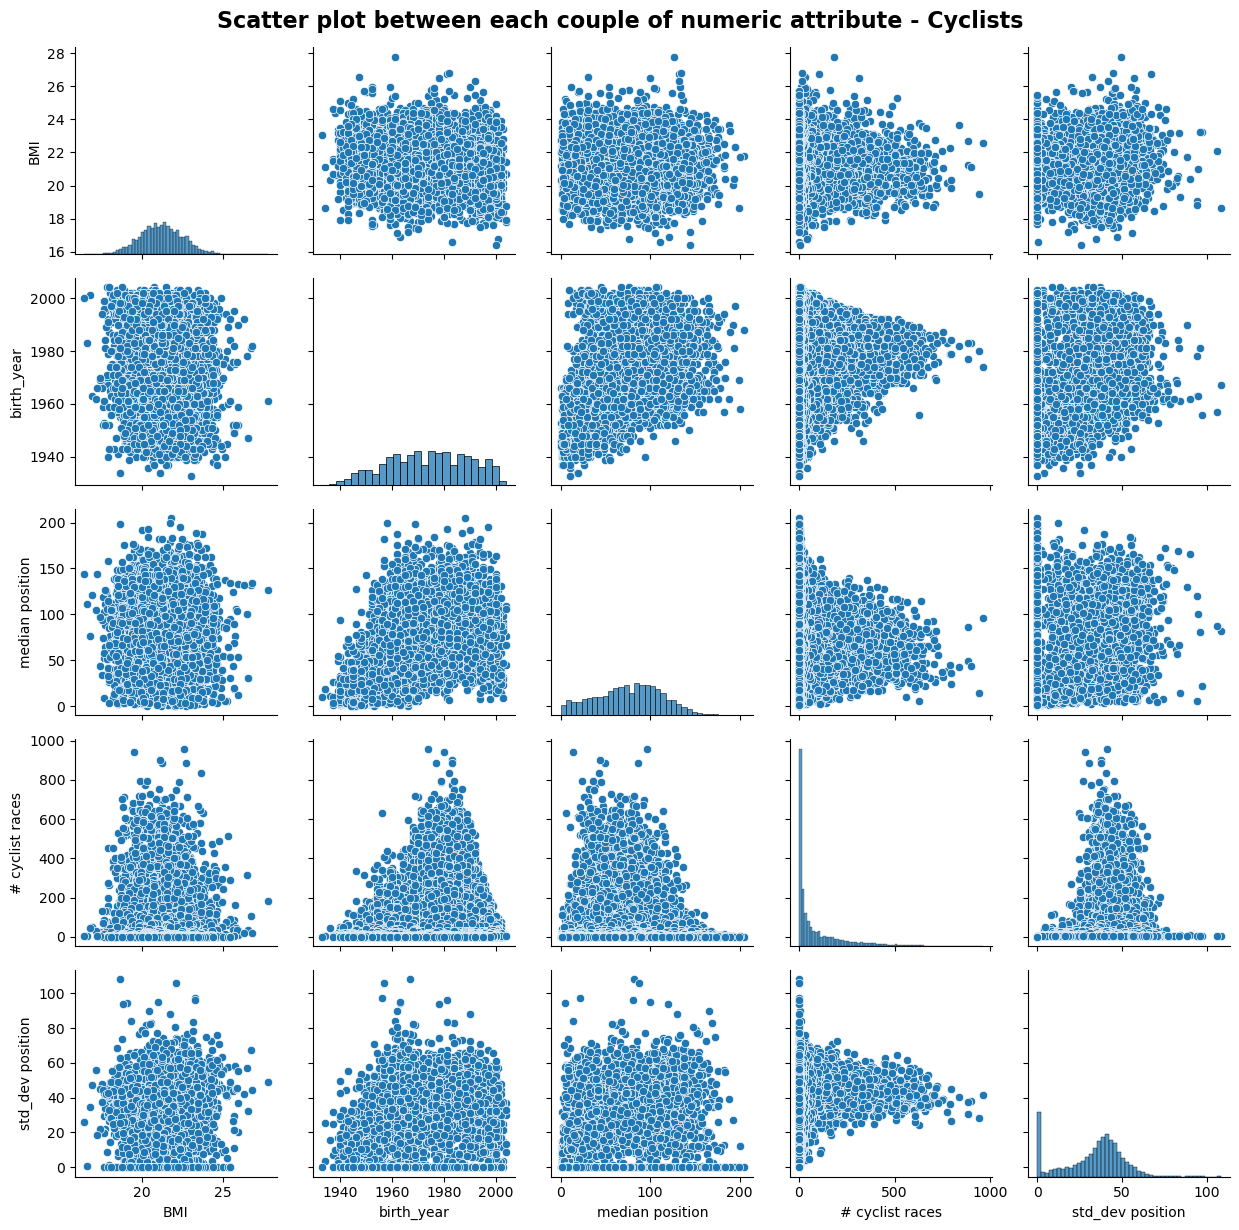

In [13]:
pairplot=sbn.pairplot(numeric_cyclists[columns])
pairplot.figure.suptitle("Scatter plot between each couple of numeric attribute - Cyclists", 
                      fontweight='bold', size=16)
pairplot.figure.tight_layout()
pairplot.figure.subplots_adjust(top=0.95)  # Adjust top margin to make space for the title
plt.show()
plt.close()

In [30]:
def generate_boxplots(df, figsize=(12, 8), cols_per_row=3):
    numeric_columns = df.select_dtypes(include=['number']).columns
    n_cols = len(numeric_columns)
    
    # Determine the number of rows required in the plot
    n_rows = (n_cols // cols_per_row) + (n_cols % cols_per_row > 0)
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=figsize, squeeze=False)
    axes = axes.ravel()
    
    for i, col in enumerate(numeric_columns):
        sbn.boxplot(data=df, y=col, ax=axes[i])
        axes[i].set_title(col, fontsize=12, fontweight='bold')
    
    #Disable useless axes, if present
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

In [28]:
def print_boxplot_stats(df):
    numeric_columns = df.select_dtypes(include=['number']).columns  # Numeric columns
    
    for col in numeric_columns:
        median = df[col].median()
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_whisker = max(df[col].min(), Q1 - 1.5 * IQR)
        upper_whisker = min(df[col].max(), Q3 + 1.5 * IQR)
        
        print(f"Column: {col}")
        print(f"  Median: {median:.2f} | Q1: {Q1:.2f} | Q3: {Q3:.2f}")
        print(f"  Lower Whisker: {lower_whisker:.2f} | Upper Whisker: {upper_whisker:.2f}")
        print("-" * 40)

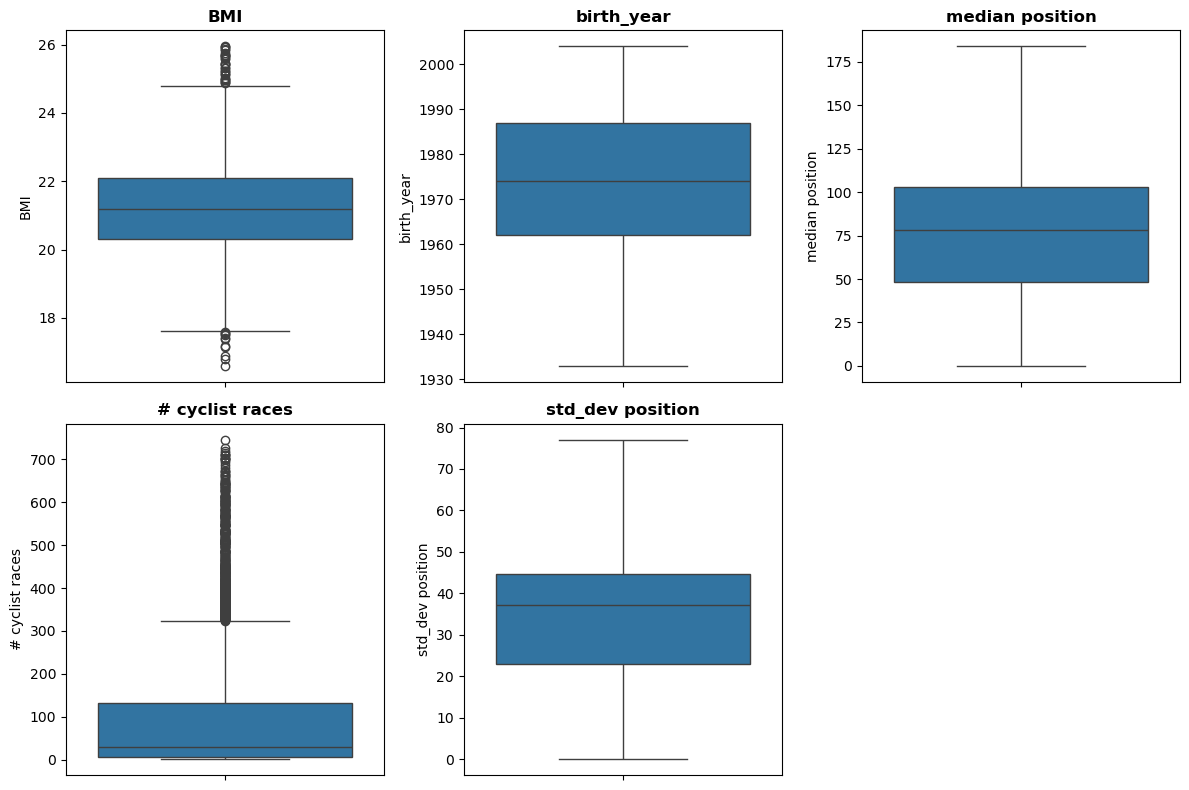

In [31]:
generate_boxplots(numeric_cyclists[columns])

In [29]:
print_boxplot_stats(numeric_cyclists[columns])

Column: BMI
  Median: 21.20 | Q1: 20.30 | Q3: 22.10
  Lower Whisker: 17.61 | Upper Whisker: 24.79
----------------------------------------
Column: birth_year
  Median: 1974.00 | Q1: 1962.00 | Q3: 1987.00
  Lower Whisker: 1933.00 | Upper Whisker: 2004.00
----------------------------------------
Column: median position
  Median: 78.00 | Q1: 48.00 | Q3: 103.00
  Lower Whisker: 0.00 | Upper Whisker: 184.00
----------------------------------------
Column: # cyclist races
  Median: 30.00 | Q1: 6.00 | Q3: 133.00
  Lower Whisker: 1.00 | Upper Whisker: 323.50
----------------------------------------
Column: std_dev position
  Median: 37.10 | Q1: 22.90 | Q3: 44.77
  Lower Whisker: 0.00 | Upper Whisker: 77.07
----------------------------------------


In [18]:
numeric_cyclists_pre_cut=numeric_cyclists.copy()

In [19]:
print(f"Pre cut: {numeric_cyclists.shape[0]}")

Pre cut: 6095


In [20]:
numeric_cyclists=numeric_cyclists[numeric_cyclists['median position']<185.5]

In [26]:
print(f"Post cut: {numeric_cyclists.shape[0]}")

Post cut: 6087


In [22]:
numeric_cyclists=numeric_cyclists[numeric_cyclists['std_dev position']<77.53]

In [23]:
print(f"Post cut: {numeric_cyclists.shape[0]}")

Post cut: 6070


In [24]:
numeric_cyclists=numeric_cyclists[(numeric_cyclists['BMI']<26)&(numeric_cyclists['BMI']>16.5)]

In [25]:
print(f"Post cut: {numeric_cyclists.shape[0]}")

Post cut: 6063


In [26]:
numeric_cyclists=numeric_cyclists[numeric_cyclists['# cyclist races']<750]

The '# cyclist races' feature has a long tail distribution so we do not cut precisely on the upper wisker value.

In [27]:
print(f"Post cut: {numeric_cyclists.shape[0]}")

Post cut: 6052


#### Races

In [32]:
columns=['points', 'length', 'startlist_quality', 'median_delta', 'climb/length']

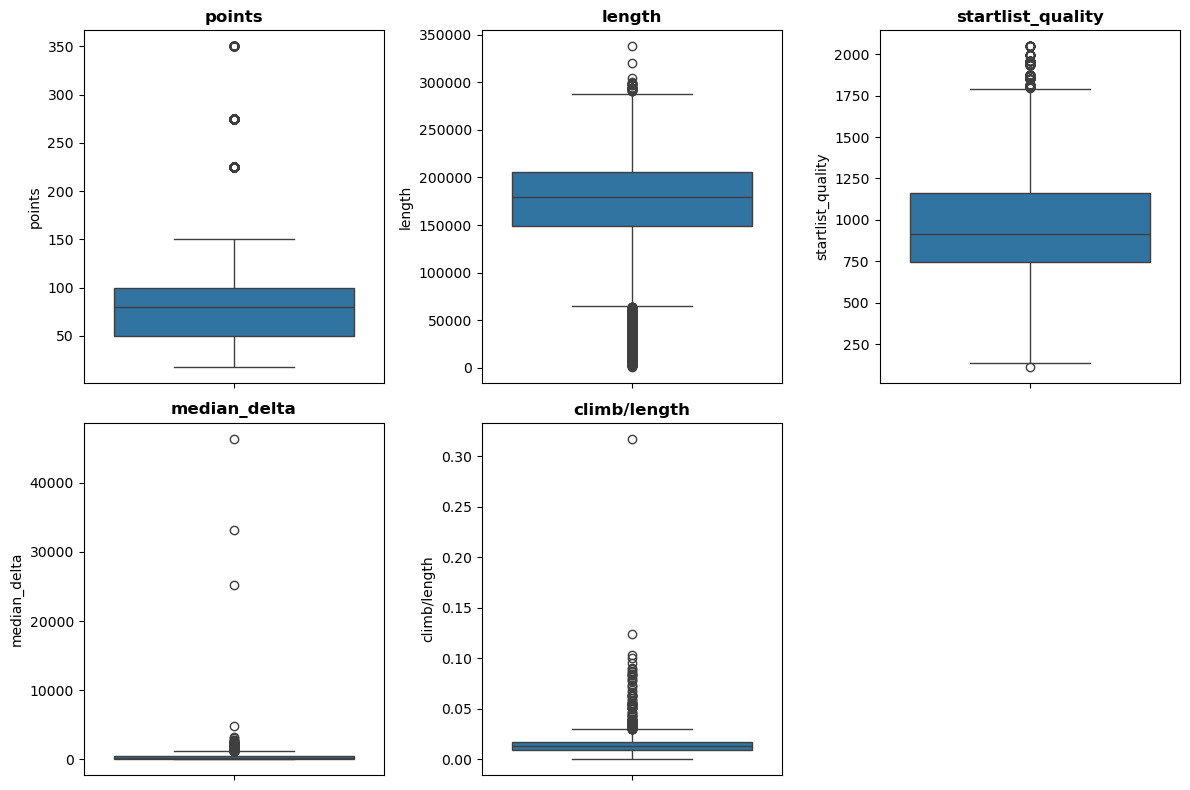

In [34]:
generate_boxplots(numeric_races[columns])

In [40]:
print_boxplot_stats(numeric_races[columns])

Column: points
  Median: 80.00 | Q1: 50.00 | Q3: 100.00
  Lower Whisker: 18.00 | Upper Whisker: 175.00
----------------------------------------
Column: length
  Median: 179000.00 | Q1: 149000.00 | Q3: 205500.00
  Lower Whisker: 64250.00 | Upper Whisker: 290250.00
----------------------------------------
Column: startlist_quality
  Median: 917.00 | Q1: 747.25 | Q3: 1165.00
  Lower Whisker: 120.62 | Upper Whisker: 1791.62
----------------------------------------
Column: median_delta
  Median: 112.25 | Q1: 5.00 | Q3: 475.50
  Lower Whisker: 0.00 | Upper Whisker: 1181.25
----------------------------------------
Column: climb/length
  Median: 0.01 | Q1: 0.01 | Q3: 0.02
  Lower Whisker: 0.00 | Upper Whisker: 0.03
----------------------------------------


In [50]:
numeric_races_pre_cut=numeric_races.copy()

In [48]:
numeric_races=numeric_races_pre_cut

In [51]:
print(f"Pre cut: {numeric_races.shape[0]}")

Pre cut: 5281


Since points is a discriminative attribute we decide not to make cuts on it.

In [52]:
numeric_races=numeric_races[numeric_races['median_delta']<20000]

In [53]:
print(f"Post cut: {numeric_races.shape[0]}")

Post cut: 5278


In [44]:
numeric_races=numeric_races[numeric_races['climb/length']<0.11]

In [45]:
print(f"Post cut: {numeric_races.shape[0]}")

Post cut: 5276


In [46]:
numeric_races=numeric_races[numeric_races['startlist_quality']<1791]

In [47]:
print(f"Post cut: {numeric_races.shape[0]}")

Post cut: 4996
